**Exercise 5: Comparison of CNN and MLP for Image classification task**

In this workbook, we use Convolution Neural Network (CNN) and Multi Layer Perceptron (MLP) for the image classification task. Precisely, we compare the prediction accuracy and required number of training parameters used by both the networks.

Next, we import necessary modules. The main purpose is to use these modules for ML tasks but also for downloading standard datasets such as MNIST. In addition, it also includes packages for data handling and visualization.

In [124]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

We check if GPU is available else we continue computations on CPU. Note that colab has dynamic and unpublished limits on the GPU usage. Finally, we decide which kind of neural network we would like to use by either defining "mlp" (for Multi Layer Perceptron) or "cnn" (for Convolution Neural Network).

In [125]:
if torch.cuda.is_available(): # Check if CUDA is available
  device = "cuda:0"
else:
  device = "cpu"

net_model = "cnn" # "cnn" or "mlp"

Next, the input data is downloaded, if not done already else we use existing input data. Note that the input data is split into training set and test set. We also understand how data is organised. **Task**: Please check PyTorch documentation to understand the purpose of `transform=ToTensor()`.

In [126]:
root_dir = "data"

if os.path.exists(root_dir):
  print("Found downloaded data")
  train_data = datasets.MNIST(root=root_dir, download=False, train=True, transform=ToTensor())
  test_data = datasets.MNIST(root=root_dir, download=False, train=False, transform=ToTensor())
else:
  print("Downloading data")
  train_data = datasets.MNIST(root=root_dir, download=True, train=True, transform=ToTensor())
  test_data = datasets.MNIST(root=root_dir, download=True, train=False, transform=ToTensor())

print(f"Training data: {train_data}, \n Input size: {train_data.data.size()}, \n Output size: {train_data.targets.size()}")
print("")
print(f"Testing data: {test_data}, \n Input size: {test_data.data.size()}, \n Output size: {test_data.targets.size()}")

Found downloaded data
Training data: Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor(), 
 Input size: torch.Size([60000, 28, 28]), 
 Output size: torch.Size([60000])

Testing data: Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor(), 
 Input size: torch.Size([10000, 28, 28]), 
 Output size: torch.Size([10000])


We visualize image with its true label.

Text(0.5, 1.0, '5')

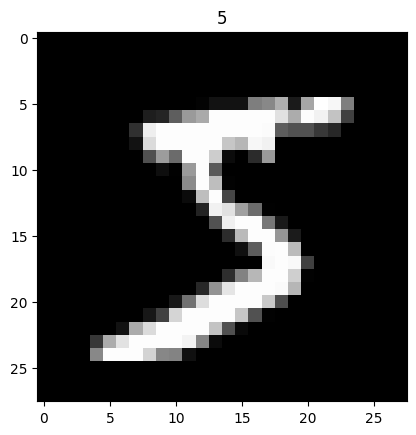

In [127]:
plt.imshow(train_data.data[0], cmap="gray")
plt.title("%i" %train_data.targets[0])

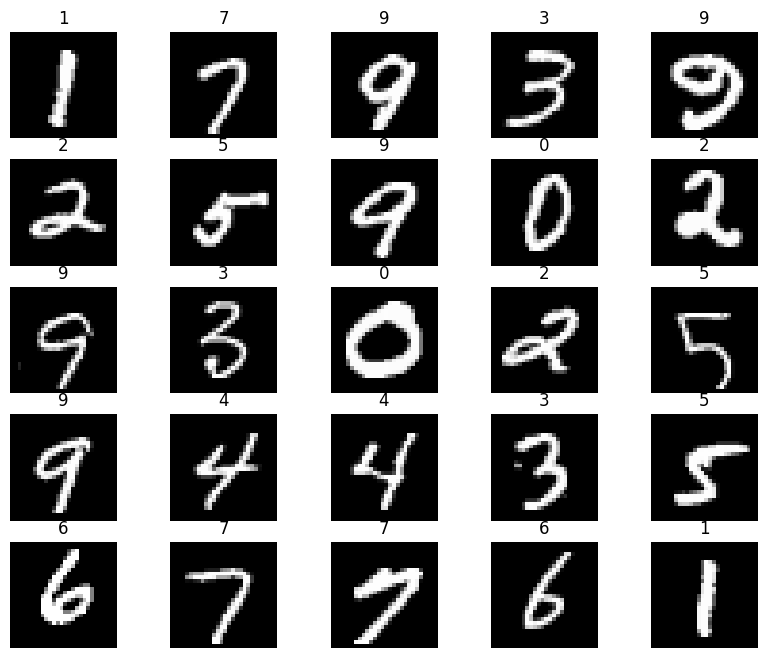

In [128]:
figure = plt.figure(figsize=(10, 8))
cols = 5
for i in range(1, cols**2 + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(cols, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

```DataLoader``` wraps an iterable around ```Dataset``` for easy access. During ANN training, data can be passed in minibatches with size specified by ```batch_size```, can be shuffled at every epoch by ```shuffle=True``` and speed up data retrieval.

In [129]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=100, shuffle=True) # Define training Dataloader
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=10000, shuffle=False) # Define testing Dataloader

We now define the Artificial Neural Network (ANN). ```torch.nn.Module``` is base class for ANN modules. Class ```net``` should should implement ```forward``` method, which implements forward pass of the ANN. Weights and biases of the ANN can be read from ```.parameters()```. ANN can be moved to a device by specifying ```device``` and data type of weights and biases can be specified by ```dtype```.

In [130]:
# Convolution Neural Network
class CNN(torch.nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = torch.nn.Sequential(
        torch.nn.Conv2d(
            in_channels = 1,
            out_channels = 16,
            kernel_size = (5, 5),
            stride = 1,
            padding = 2,
        ),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d((2, 2)),
    )

    self.conv2 = torch.nn.Sequential(
        torch.nn.Conv2d(
            in_channels = 16,
            out_channels = 4,
            kernel_size = (5, 5),
            stride = 1,
            padding = 2,
        ),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d((2, 2)),
    )

    self.out = torch.nn.Linear(4 * 7 * 7, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = x.view(x.size(0), -1)
    output = self.out(x)
    return output

# Multi Layer Perceptron
class MLP(torch.nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):

    super().__init__()
    self.input_size = input_size
    self.fc1 = torch.nn.Linear(input_size, hidden_size)
    self.relu = torch.nn.ReLU()
    self.fc2 = torch.nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    x = x.view(-1, self.input_size_flat(x))
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)

    return x

  def input_size_flat(self, x):
    return x.size(1) * x.size(2) * x.size(3)

if net_model == "cnn":
  net = CNN()
elif net_model == "mlp":
  net = MLP(784, 128, 10)

net.to(device=device)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=196, out_features=10, bias=True)
)

Next we define ``loss_func`` and ``optimizer``. ``loss_func`` measures error between prediction and true value while ``optimizer`` is used to minimise error between true value and prediction.

In [131]:
loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1.e-2)

Next, the training of neural network is performed. We define maximum number of epochs and define training and testing loop. During training the Neural Network tries to minimise the error using training set while during testing the error or loss is assessed over test set.

In [132]:
max_epochs = 10

def train(max_epochs, net, train_dataloader):
  for epoch in range(max_epochs):
    net.train()
    for batch_num, (image_batch, label_batch) in enumerate(train_dataloader):
      image_batch.to(device=device)
      label_batch.to(device=device)
      pred = net(image_batch)
      loss = loss_func(pred, label_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      if (batch_num + 1) % 100 == 0:
        print (f"Epoch: {epoch+1}/{max_epochs}, Batch: {batch_num+1}/{len(train_dataloader)}, Loss: {loss.item()}")

train(max_epochs, net, train_dataloader)

Epoch: 1/10, Batch: 100/600, Loss: 0.18261995911598206
Epoch: 1/10, Batch: 200/600, Loss: 0.17275618016719818
Epoch: 1/10, Batch: 300/600, Loss: 0.08210325241088867
Epoch: 1/10, Batch: 400/600, Loss: 0.14249888062477112
Epoch: 1/10, Batch: 500/600, Loss: 0.12346590310335159
Epoch: 1/10, Batch: 600/600, Loss: 0.15463005006313324
Epoch: 2/10, Batch: 100/600, Loss: 0.05757928267121315
Epoch: 2/10, Batch: 200/600, Loss: 0.02632823772728443
Epoch: 2/10, Batch: 300/600, Loss: 0.0894734263420105
Epoch: 2/10, Batch: 400/600, Loss: 0.008562610484659672
Epoch: 2/10, Batch: 500/600, Loss: 0.0902554914355278
Epoch: 2/10, Batch: 600/600, Loss: 0.07145541906356812
Epoch: 3/10, Batch: 100/600, Loss: 0.012208273634314537
Epoch: 3/10, Batch: 200/600, Loss: 0.013298282399773598
Epoch: 3/10, Batch: 300/600, Loss: 0.028728589415550232
Epoch: 3/10, Batch: 400/600, Loss: 0.10599307715892792
Epoch: 3/10, Batch: 500/600, Loss: 0.10156683623790741
Epoch: 3/10, Batch: 600/600, Loss: 0.007562040816992521
Epoch: 

In [133]:
def test(net, test_dataloader):
  net.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for batch_num, (image_batch, label_batch) in enumerate(test_dataloader):
      pred = net(image_batch)
      loss = loss_func(pred, label_batch)
      pred = torch.max(pred, 1)[1]
      accuracy = (pred == label_batch).sum() / label_batch.size(0)
      print(f"Batch: {batch_num + 1}/{len(test_dataloader)}, Accuracy: {accuracy}")

test(net, test_dataloader)

Batch: 1/1, Accuracy: 0.9829999804496765


In [134]:
num_trainable_para = 0
for param in net.parameters():
  if param.requires_grad == True:
    # print(np.prod(param.shape))
    num_trainable_para += np.prod(param.shape)

print(f"Number of learnable model parameters: {num_trainable_para}")

Number of learnable model parameters: 3990


Finally, we visualise the image with its prediction and True labels.

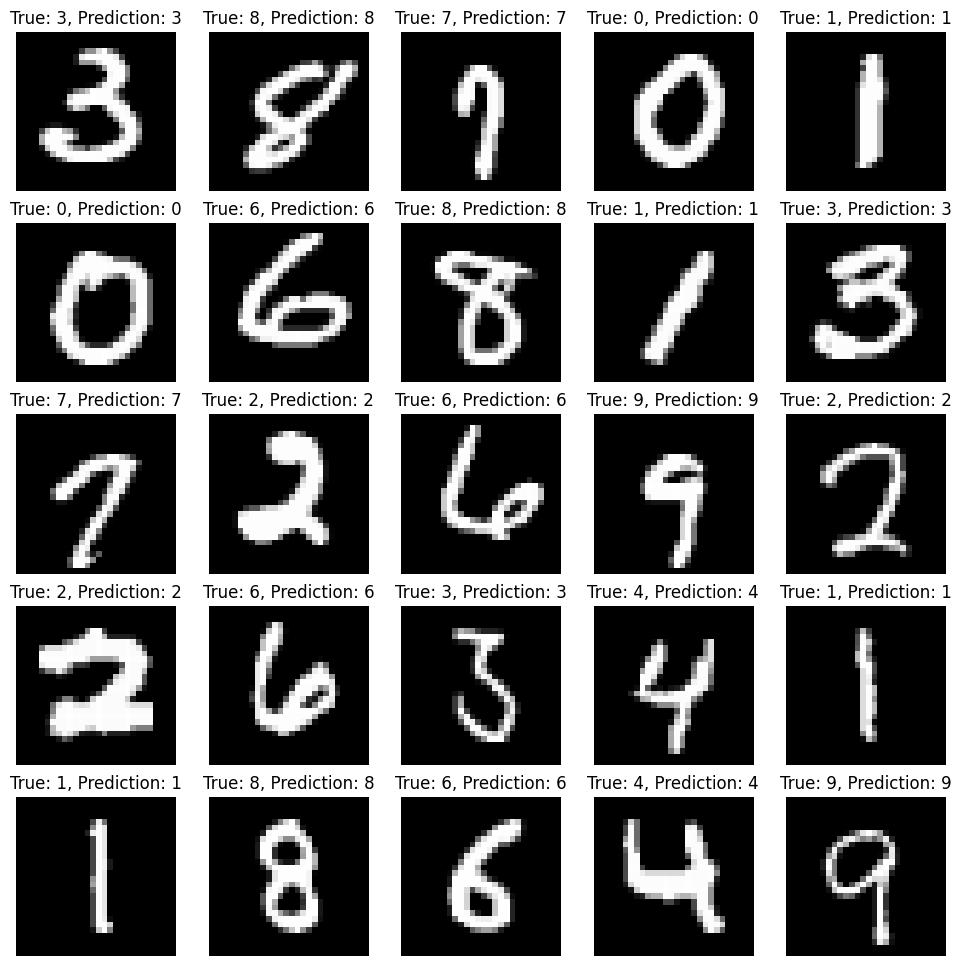

In [135]:
figure = plt.figure(figsize=(12, 12))
num_test_samples_sqrt = 5
for i in range(1, num_test_samples_sqrt**2 + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]
    pred = net(img.unsqueeze(0))
    pred = torch.max(pred, 1)[1].data.numpy().squeeze()
    figure.add_subplot(num_test_samples_sqrt, num_test_samples_sqrt, i)
    plt.title(f"True: {label}, Prediction: {pred}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

**Summary**: It can be observed that CNN achieves higher accuracy (approximately 98.30%) with roughly 4000 learnable parameters as compared to MLP, which achieves accuracy of  approximately 97.35% with very high number of learnable parameters (more than 100000 parameters).

**Task**: Compare run-time of training with CNN and MLP.